# Taylor and Maclaurin Series - Symbolic Computation
## Comprehensive Guide with Examples and Assignments

### Learning Objectives:
1. Understand Taylor and Maclaurin series expansions
2. Compute series symbolically using SymPy
3. Analyze truncation errors
4. Visualize series approximations
5. Apply to real-world problems

## 1. Setup and Imports

In [2]:
# Install required packages (if needed)
# !pip install sympy numpy matplotlib

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, exp, sin, cos, log, sqrt, atan, factorial
from sympy import series, lambdify, diff, Function
from IPython.display import display, Math, Latex

# Enable pretty printing
sp.init_printing(use_unicode=True)

print("Setup complete!")

Setup complete!


## 2. Theory Review

### Taylor Series
The Taylor series of a function $f(x)$ about point $a$ is:

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \cdots$$

### Maclaurin Series
When $a = 0$, the Taylor series becomes the Maclaurin series:

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!}x^n = f(0) + f'(0)x + \frac{f''(0)}{2!}x^2 + \cdots$$

## 3. Basic Taylor Series Computation

In [23]:
def compute_taylor_series(func, point, degree, variable=None):
    """
    Compute Taylor series expansion of a function.
    
    Parameters:
    -----------
    func : sympy expression
        The function to expand
    point : float
        The point about which to expand
    degree : int
        The degree of the polynomial approximation
    variable : sympy symbol (optional)
        The variable of the function
    
    Returns:
    --------
    series_expansion : sympy expression
        The Taylor series polynomial
    """
    if variable is None:
        variable = list(func.free_symbols)[0]
    
    # Compute Taylor series
    taylor_series = sp.series(func, variable, point, n=degree+1).removeO()
    
    return taylor_series

# Test the function
x = symbols('x')
f = exp(x)
taylor_exp = compute_taylor_series(f, 0, 5)

print("Taylor series of e^x about x=0 up to degree 5:")
display(taylor_exp)

Taylor series of e^x about x=0 up to degree 5:


## 4. Maclaurin Series for Common Functions

In [24]:
x = symbols('x')
degree = 6

# Dictionary of common functions
functions = {
    'e^x': exp(x),
    'sin(x)': sin(x),
    'cos(x)': cos(x),
    'ln(1+x)': log(1+x),
    '1/(1-x)': 1/(1-x),
    'arctan(x)': atan(x)
}

print(f"Maclaurin Series (up to degree {degree}):\n")
print("="*60)

for name, func in functions.items():
    maclaurin = compute_taylor_series(func, 0, degree)
    print(f"\n{name}:")
    display(maclaurin)
    print("-"*60)

Maclaurin Series (up to degree 6):


e^x:


------------------------------------------------------------

sin(x):


------------------------------------------------------------

cos(x):


------------------------------------------------------------

ln(1+x):


------------------------------------------------------------

1/(1-x):


------------------------------------------------------------

arctan(x):


------------------------------------------------------------


## 5. Manual Taylor Series Computation

In [5]:
def manual_taylor_series(func, point, degree, variable=None):
    """
    Manually compute Taylor series using derivative formula.
    """
    if variable is None:
        variable = list(func.free_symbols)[0]
    
    result = 0
    
    print(f"Computing Taylor series of {func} about x={point}:\n")
    
    for n in range(degree + 1):
        # Compute nth derivative
        derivative = diff(func, variable, n)
        
        # Evaluate at the point
        derivative_at_point = derivative.subs(variable, point)
        
        # Compute term
        term = derivative_at_point / factorial(n) * (variable - point)**n
        
        print(f"n={n}: f^({n})({point}) = {derivative_at_point}, "
              f"term = {sp.simplify(term)}")
        
        result += term
    
    return sp.simplify(result)

# Example: sin(x) about x=0
x = symbols('x')
result = manual_taylor_series(sin(x), 0, 5)
print("\nFinal result:")
display(result)

Computing Taylor series of sin(x) about x=0:

n=0: f^(0)(0) = 0, term = 0
n=1: f^(1)(0) = 1, term = x
n=2: f^(2)(0) = 0, term = 0
n=3: f^(3)(0) = -1, term = -x**3/6
n=4: f^(4)(0) = 0, term = 0
n=5: f^(5)(0) = 1, term = x**5/120

Final result:


## 6. Error Analysis

In [6]:
def analyze_error(func, taylor_approx, point_range, variable=None):
    """
    Analyze the error between original function and Taylor approximation.
    """
    if variable is None:
        variable = list(func.free_symbols)[0]
    
    # Convert to numerical functions
    f_numeric = lambdify(variable, func, 'numpy')
    taylor_numeric = lambdify(variable, taylor_approx, 'numpy')
    
    # Generate points
    x_vals = np.linspace(point_range[0], point_range[1], 1000)
    
    # Compute values
    try:
        f_vals = f_numeric(x_vals)
        taylor_vals = taylor_numeric(x_vals)
        
        # Compute errors
        absolute_error = np.abs(f_vals - taylor_vals)
        relative_error = np.abs((f_vals - taylor_vals) / f_vals) * 100
        
        # Statistics
        print(f"Error Analysis over [{point_range[0]}, {point_range[1]}]:")
        print(f"Max Absolute Error: {np.max(absolute_error):.6e}")
        print(f"Mean Absolute Error: {np.mean(absolute_error):.6e}")
        print(f"Max Relative Error: {np.max(relative_error):.6f}%")
        
        return x_vals, absolute_error, relative_error
    except:
        print("Error in computation - possibly division by zero or complex values")
        return None, None, None

# Example: e^x
x = symbols('x')
func = exp(x)
taylor_approx = compute_taylor_series(func, 0, 5)

x_vals, abs_err, rel_err = analyze_error(func, taylor_approx, [-1, 1])

Error Analysis over [-1, 1]:
Max Absolute Error: 1.615162e-03
Mean Absolute Error: 2.024093e-04
Max Relative Error: 0.329666%


## 7. Visualization Functions

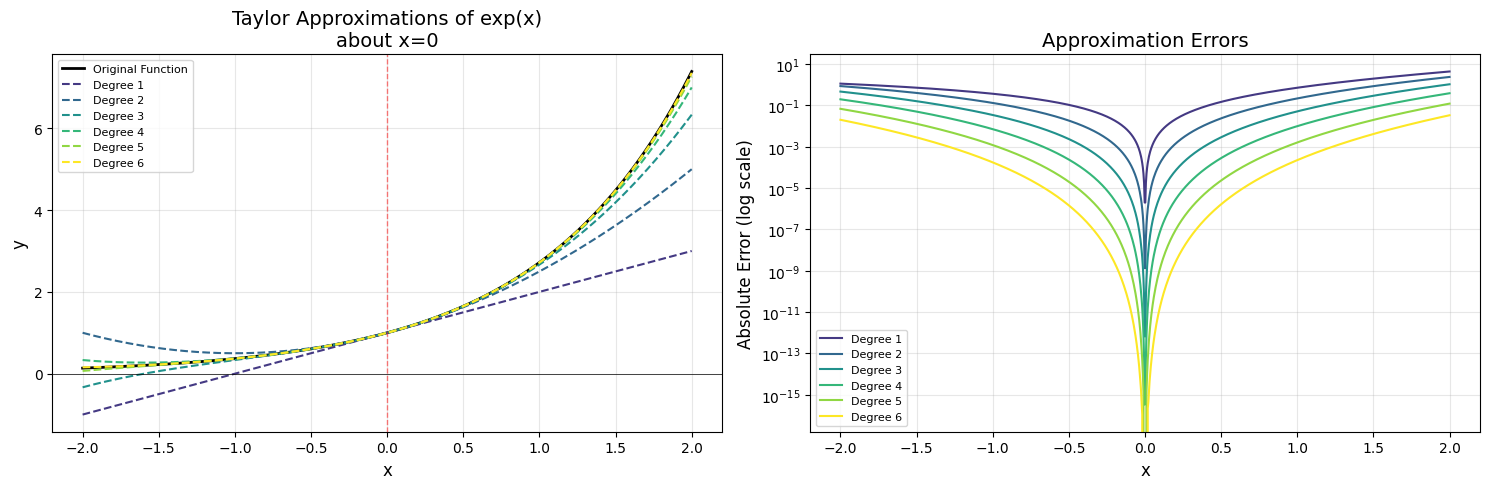

In [7]:
def plot_taylor_approximations(func, center, max_degree, x_range, variable=None):
    """
    Plot function and its Taylor approximations of various degrees.
    """
    if variable is None:
        variable = list(func.free_symbols)[0]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Generate x values
    x_vals = np.linspace(x_range[0], x_range[1], 1000)
    
    # Plot original function
    f_numeric = lambdify(variable, func, 'numpy')
    try:
        y_original = f_numeric(x_vals)
        ax1.plot(x_vals, y_original, 'k-', linewidth=2, label='Original Function')
    except:
        print("Could not plot original function")
    
    # Plot Taylor approximations
    colors = plt.cm.viridis(np.linspace(0, 1, max_degree+1))
    
    for degree in range(0, max_degree+1):
        taylor = compute_taylor_series(func, center, degree, variable)
        taylor_numeric = lambdify(variable, taylor, 'numpy')
        
        try:
            y_taylor = taylor_numeric(x_vals)
            ax1.plot(x_vals, y_taylor, color=colors[degree], 
                    linestyle='--', label=f'Degree {degree}')
            
            # Plot error
            if degree > 0:
                error = np.abs(y_original - y_taylor)
                ax2.semilogy(x_vals, error, color=colors[degree], 
                           label=f'Degree {degree}')
        except:
            pass
    
    # Formatting
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('y', fontsize=12)
    ax1.set_title(f'Taylor Approximations of {func}\nabout x={center}', fontsize=14)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax1.axvline(x=center, color='r', linestyle='--', linewidth=1, alpha=0.5)
    
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('Absolute Error (log scale)', fontsize=12)
    ax2.set_title('Approximation Errors', fontsize=14)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example
x = symbols('x')
plot_taylor_approximations(exp(x), 0, 6, [-2, 2])

## 8. Interactive Examples

EXAMPLE 1: Exponential Function e^x


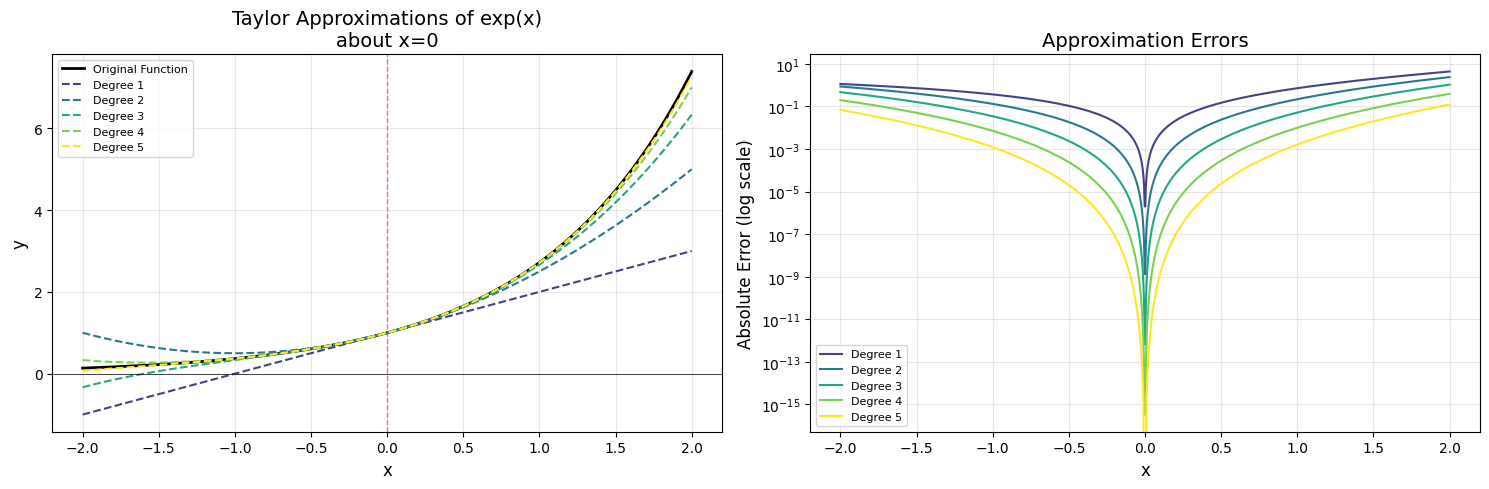

In [8]:
# Example 1: Exponential Function
print("EXAMPLE 1: Exponential Function e^x")
print("="*60)
x = symbols('x')
plot_taylor_approximations(exp(x), 0, 5, [-2, 2])

EXAMPLE 2: Sine Function sin(x)


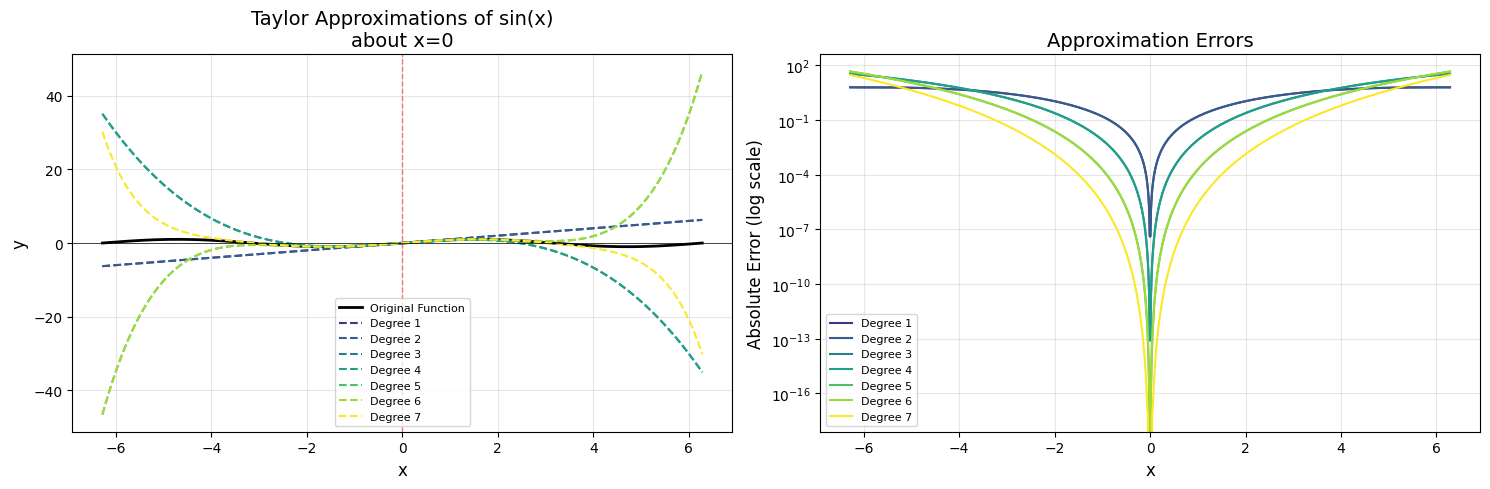

In [9]:
# Example 2: Sine Function
print("EXAMPLE 2: Sine Function sin(x)")
print("="*60)
plot_taylor_approximations(sin(x), 0, 7, [-2*np.pi, 2*np.pi])

EXAMPLE 3: Cosine Function cos(x)


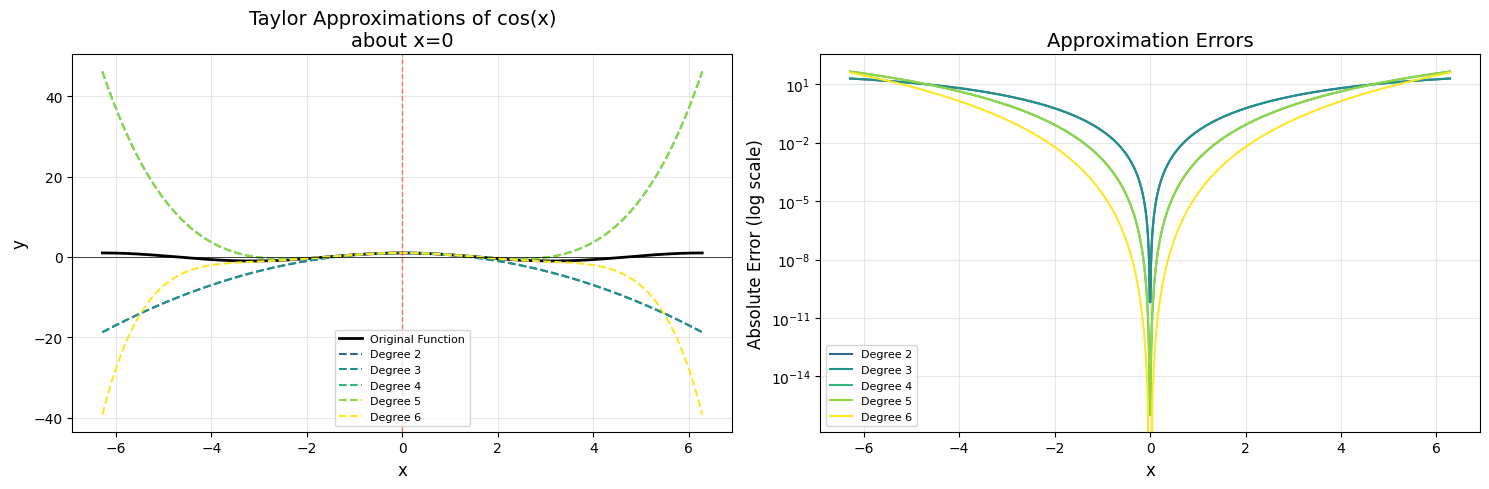

In [10]:
# Example 3: Cosine Function
print("EXAMPLE 3: Cosine Function cos(x)")
print("="*60)
plot_taylor_approximations(cos(x), 0, 6, [-2*np.pi, 2*np.pi])

EXAMPLE 4: Natural Logarithm ln(1+x)


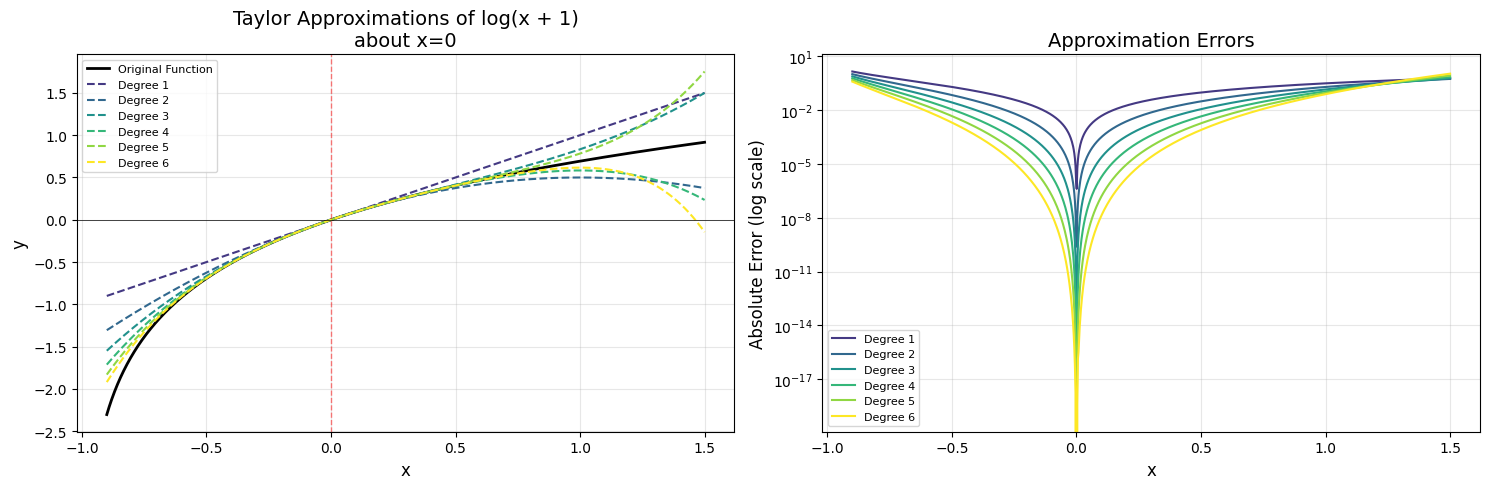

In [11]:
# Example 4: Natural Logarithm
print("EXAMPLE 4: Natural Logarithm ln(1+x)")
print("="*60)
plot_taylor_approximations(log(1+x), 0, 6, [-0.9, 1.5])

EXAMPLE 5: sin(x) about x=π/2


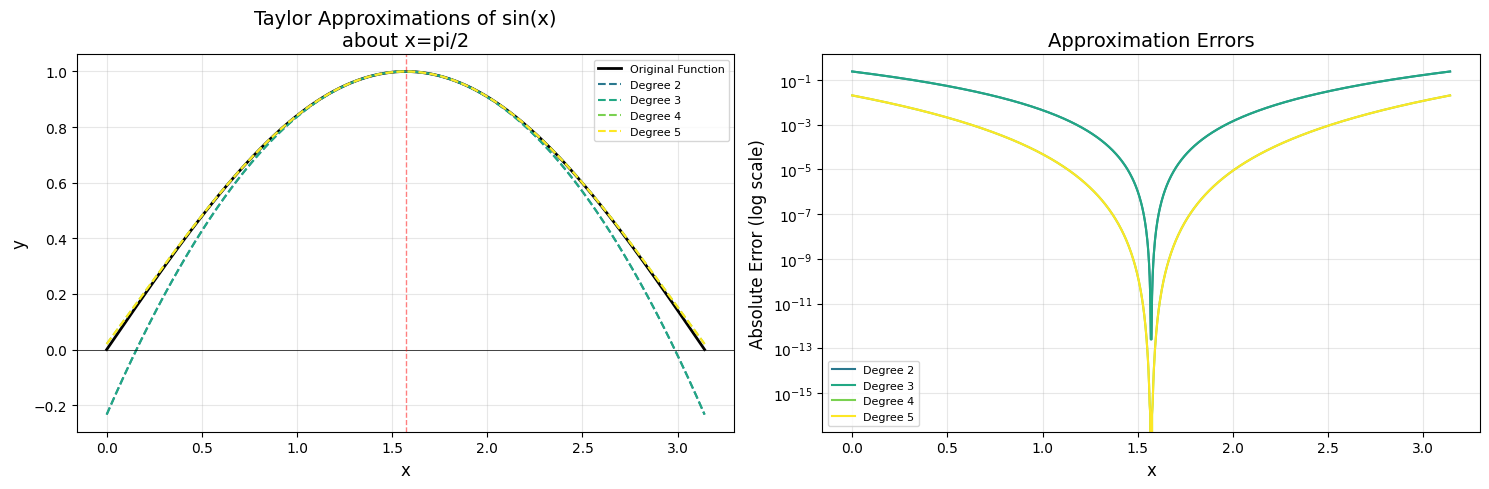

In [12]:
# Example 5: Taylor series about non-zero point
print("EXAMPLE 5: sin(x) about x=π/2")
print("="*60)
plot_taylor_approximations(sin(x), sp.pi/2, 5, [0, np.pi])

## 9. Convergence Analysis

Convergence analysis for exp(x) at x=1.0
True value: 2.718281828459045

Degree    Approximation       Error               
0         1.0000000000        1.72e+00            
1         2.0000000000        7.18e-01            
2         2.5000000000        2.18e-01            
3         2.6666666667        5.16e-02            
4         2.7083333333        9.95e-03            
5         2.7166666667        1.62e-03            
6         2.7180555556        2.26e-04            
7         2.7182539683        2.79e-05            
8         2.7182787698        3.06e-06            
9         2.7182815256        3.03e-07            
10        2.7182818011        2.73e-08            
11        2.7182818262        2.26e-09            
12        2.7182818283        1.73e-10            
13        2.7182818284        1.23e-11            
14        2.7182818285        8.15e-13            
15        2.7182818285        5.02e-14            


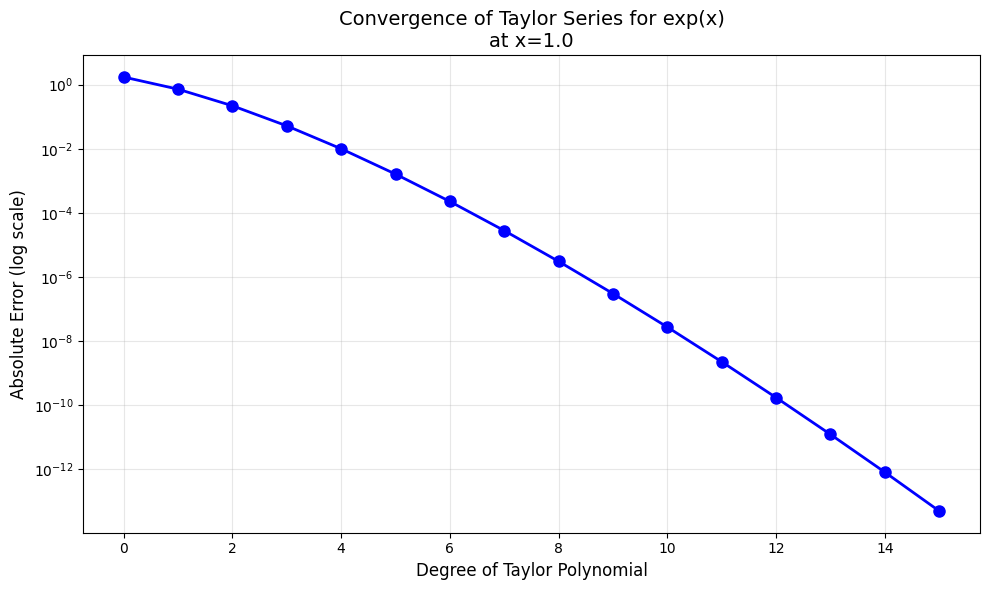

In [13]:
def convergence_analysis(func, center, max_degree, test_point, variable=None):
    """
    Analyze how error decreases as degree increases.
    """
    if variable is None:
        variable = list(func.free_symbols)[0]
    
    # True value
    true_value = float(func.subs(variable, test_point))
    
    degrees = []
    errors = []
    
    print(f"Convergence analysis for {func} at x={test_point}")
    print(f"True value: {true_value}\n")
    print(f"{'Degree':<10}{'Approximation':<20}{'Error':<20}")
    print("="*50)
    
    for degree in range(max_degree + 1):
        taylor = compute_taylor_series(func, center, degree, variable)
        approx_value = float(taylor.subs(variable, test_point))
        error = abs(true_value - approx_value)
        
        degrees.append(degree)
        errors.append(error)
        
        print(f"{degree:<10}{approx_value:<20.10f}{error:<20.2e}")
    
    # Plot convergence
    plt.figure(figsize=(10, 6))
    plt.semilogy(degrees, errors, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Degree of Taylor Polynomial', fontsize=12)
    plt.ylabel('Absolute Error (log scale)', fontsize=12)
    plt.title(f'Convergence of Taylor Series for {func}\nat x={test_point}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return degrees, errors

# Example
x = symbols('x')
convergence_analysis(exp(x), 0, 15, 1.0)

## 10. Practical Applications

In [14]:
# Application 1: Small Angle Approximation
print("APPLICATION 1: Small Angle Approximations in Physics")
print("="*60)

x = symbols('x')
angles_deg = np.array([1, 5, 10, 15, 20, 30])
angles_rad = np.deg2rad(angles_deg)

print(f"{'Angle (deg)':<12}{'sin(θ)':<15}{'θ (1st order)':<15}{'Error %':<15}")
print("-"*60)

for deg, rad in zip(angles_deg, angles_rad):
    exact = np.sin(rad)
    approx = rad
    error = abs((exact - approx) / exact) * 100
    print(f"{deg:<12}{exact:<15.6f}{approx:<15.6f}{error:<15.4f}")

print("\nConclusion: Small angle approximation sin(θ) ≈ θ is valid for θ < 10°")

APPLICATION 1: Small Angle Approximations in Physics
Angle (deg) sin(θ)         θ (1st order)  Error %        
------------------------------------------------------------
1           0.017452       0.017453       0.0051         
5           0.087156       0.087266       0.1270         
10          0.173648       0.174533       0.5095         
15          0.258819       0.261799       1.1515         
20          0.342020       0.349066       2.0600         
30          0.500000       0.523599       4.7198         

Conclusion: Small angle approximation sin(θ) ≈ θ is valid for θ < 10°


In [15]:
# Application 2: Compound Interest Approximation
print("APPLICATION 2: Compound Interest using e^x")
print("="*60)

# A = P*e^(rt)
# Using Taylor series for small r*t

P = 1000  # Principal
r = 0.05  # 5% annual rate
t = 1     # 1 year

x = symbols('x')
rt = r * t

print(f"Principal: ${P}")
print(f"Annual Rate: {r*100}%")
print(f"Time: {t} year\n")

exact = P * np.exp(rt)
print(f"Exact (e^rt): ${exact:.2f}\n")

for degree in range(1, 6):
    taylor = compute_taylor_series(exp(x), 0, degree)
    approx = float(P * taylor.subs(x, rt))
    error = abs(exact - approx)
    print(f"Degree {degree} approximation: ${approx:.2f} (error: ${error:.4f})")

APPLICATION 2: Compound Interest using e^x
Principal: $1000
Annual Rate: 5.0%
Time: 1 year

Exact (e^rt): $1051.27

Degree 1 approximation: $1050.00 (error: $1.2711)
Degree 2 approximation: $1051.25 (error: $0.0211)
Degree 3 approximation: $1051.27 (error: $0.0003)
Degree 4 approximation: $1051.27 (error: $0.0000)
Degree 5 approximation: $1051.27 (error: $0.0000)


## 11. Advanced: Custom Functions

Analyzing function: exp(-x**2)
Expansion point: x = 0
Maximum degree: 8

Taylor Series:


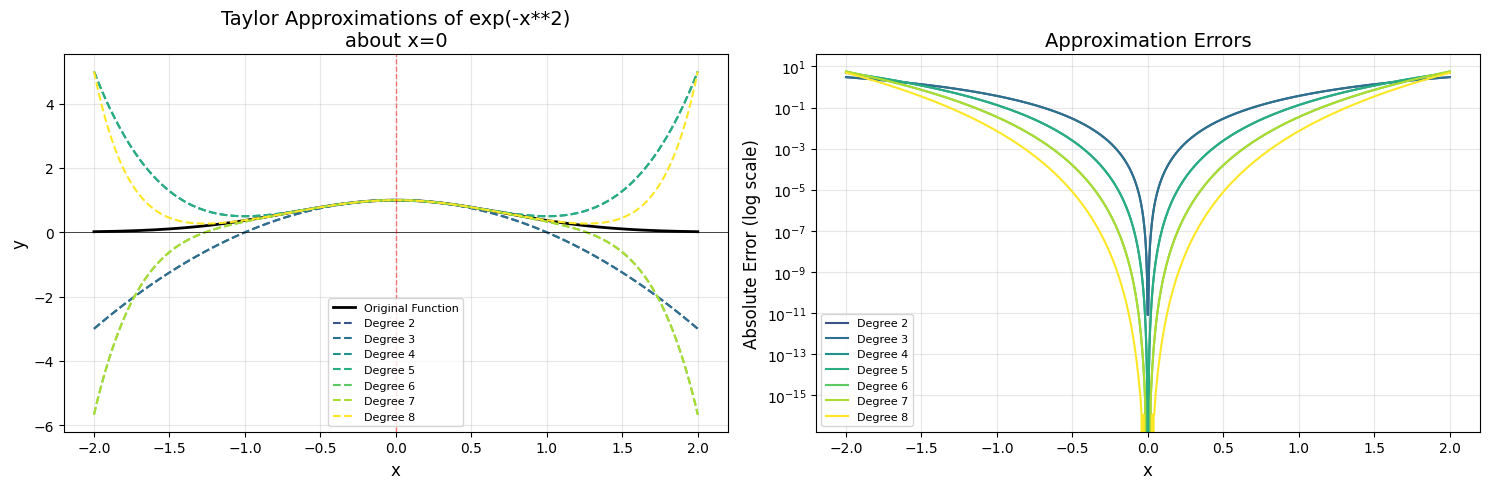

Convergence analysis for exp(-x**2) at x=0.0
True value: 1.0

Degree    Approximation       Error               
0         1.0000000000        0.00e+00            
1         1.0000000000        0.00e+00            
2         1.0000000000        0.00e+00            
3         1.0000000000        0.00e+00            
4         1.0000000000        0.00e+00            
5         1.0000000000        0.00e+00            
6         1.0000000000        0.00e+00            
7         1.0000000000        0.00e+00            
8         1.0000000000        0.00e+00            


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19944\520510568.py:36: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


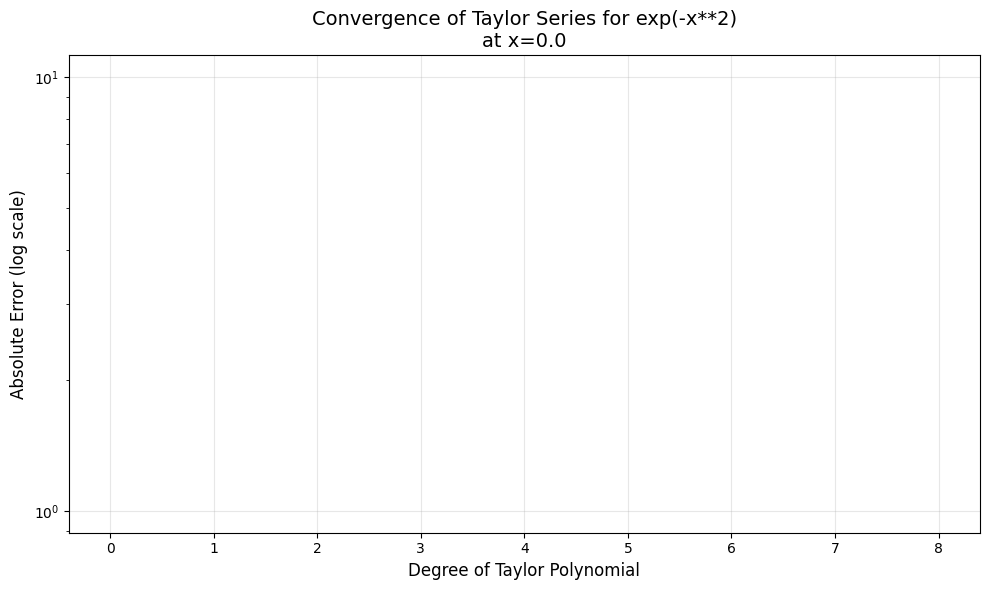

In [16]:
def analyze_custom_function(func_expr, center, degree, x_range):
    """
    Complete analysis of a custom function.
    """
    x = symbols('x')
    
    print(f"Analyzing function: {func_expr}")
    print(f"Expansion point: x = {center}")
    print(f"Maximum degree: {degree}")
    print("="*60)
    
    # Compute Taylor series
    taylor = compute_taylor_series(func_expr, center, degree)
    print("\nTaylor Series:")
    display(taylor)
    
    # Plot
    plot_taylor_approximations(func_expr, center, degree, x_range)
    
    # Convergence at specific point
    test_point = (x_range[0] + x_range[1]) / 2
    convergence_analysis(func_expr, center, degree, test_point)

# Example: Custom function
x = symbols('x')
custom_func = exp(-x**2)  # Gaussian function
analyze_custom_function(custom_func, 0, 8, [-2, 2])

---
# ASSIGNMENTS
---

## Assignment 1: Basic Maclaurin Series (10 points)

**Task:** Compute the Maclaurin series for the following functions up to degree 6:

1. $f(x) = \sinh(x) = \frac{e^x - e^{-x}}{2}$
2. $f(x) = \cosh(x) = \frac{e^x + e^{-x}}{2}$
3. $f(x) = \frac{1}{1+x^2}$

For each function:
- Display the symbolic series
- Plot the function and approximations
- Compute the error at x = 0.5

In [17]:
# YOUR CODE HERE for Assignment 1
# Solution template:

x = symbols('x')

# Function 1: sinh(x)
# TODO: Complete this

# Function 2: cosh(x)
# TODO: Complete this

# Function 3: 1/(1+x^2)
# TODO: Complete this

## Assignment 2: Taylor Series About Non-Zero Points (15 points)

**Task:** Compute Taylor series about the specified points:

1. $\ln(x)$ about $x = 1$ (degree 5)
2. $\sqrt{x}$ about $x = 1$ (degree 4)
3. $\cos(x)$ about $x = \pi/4$ (degree 6)

For each:
- Manually compute the first 3 terms showing all derivatives
- Verify with SymPy
- Plot and analyze errors in the range near the expansion point

In [18]:
# YOUR CODE HERE for Assignment 2
# Solution template:

x = symbols('x')

# 1. ln(x) about x=1
print("Manual computation for ln(x):")
# TODO: Show derivative calculations

# 2. sqrt(x) about x=1
# TODO: Complete this

# 3. cos(x) about x=π/4
# TODO: Complete this

Manual computation for ln(x):


## Assignment 3: Error Analysis and Convergence (20 points)

**Task:** Perform comprehensive error analysis:

1. For $f(x) = e^x$ centered at $x=0$:
   - Plot absolute and relative errors for degrees 1-10 at $x=1$
   - Find minimum degree needed for error < $10^{-6}$ at $x=1$
   - Determine radius of convergence empirically

2. For $f(x) = \sin(x)$ centered at $x=0$:
   - Compare errors at $x = \pi/6, \pi/4, \pi/2, \pi$
   - Create a heatmap showing error vs. (degree, x-value)

3. Write a function that determines the minimum degree needed for a specified accuracy

In [19]:
# YOUR CODE HERE for Assignment 3

def find_minimum_degree(func, center, target_error, test_point, max_degree=50):
    """
    Find minimum degree for specified error tolerance.
    
    Returns: minimum degree or None if not found
    """
    # TODO: Implement this function
    pass

# TODO: Complete the analysis tasks

## Assignment 4: Real-World Application (25 points)

**Scenario:** You're designing a calculator chip with limited memory. You need to approximate trigonometric functions using polynomial approximations.

**Tasks:**

1. Design polynomial approximations for $\sin(x)$ and $\cos(x)$ valid for $x \in [0, \pi/2]$
   - Determine minimum degree for 6 decimal places accuracy
   - Verify accuracy across the range

2. Implement a function that:
   - Takes any angle in radians
   - Reduces it to $[0, \pi/2]$ using symmetry
   - Computes sin/cos using your polynomial
   - Compares with numpy's implementation

3. Analyze memory requirements vs accuracy trade-off

In [20]:
# YOUR CODE HERE for Assignment 4

def polynomial_sin(angle, degree=7):
    """
    Compute sin using Taylor polynomial.
    Handle angle reduction to [0, π/2]
    """
    # TODO: Implement
    pass

def polynomial_cos(angle, degree=7):
    """
    Compute cos using Taylor polynomial.
    """
    # TODO: Implement
    pass

# TODO: Test and analyze

## Assignment 5: Advanced - Multivariate Taylor Series (30 points)

**Task:** Extend to functions of two variables:

1. Derive and implement 2D Taylor series for $f(x,y) = e^{x+y}$ about $(0,0)$
2. Compute series for $f(x,y) = \sin(x)\cos(y)$ up to degree 4
3. Create 3D surface plots showing:
   - Original function
   - Approximations of various degrees
   - Error surface
4. Analyze how error grows with distance from center point

In [21]:
# YOUR CODE HERE for Assignment 5
from mpl_toolkits.mplot3d import Axes3D

x, y = symbols('x y')

def taylor_2d(func, point, degree):
    """
    Compute 2D Taylor series.
    
    point: tuple (x0, y0)
    """
    # TODO: Implement 2D Taylor expansion
    pass

# TODO: Complete the analysis

## Assignment 6: Comparison and Optimization (20 points)

**Task:** Compare different expansion strategies:

1. For $f(x) = e^x$ on $[-2, 2]$:
   - Maclaurin series (center at 0)
   - Taylor series at optimal center
   - Piecewise Taylor approximations

2. Find the optimal expansion point that minimizes maximum error

3. Compare computational cost vs accuracy for each method

4. Create a comprehensive report with visualizations

In [22]:
# YOUR CODE HERE for Assignment 6

def find_optimal_center(func, x_range, degree, num_tests=100):
    """
    Find optimal expansion point to minimize max error.
    """
    # TODO: Implement optimization
    pass

# TODO: Complete comparison

---
## Grading Rubric

| Assignment | Points | Criteria |
|------------|--------|----------|
| 1 | 10 | Correct series, plots, error calculations |
| 2 | 15 | Manual calculations shown, verification, analysis |
| 3 | 20 | Comprehensive error analysis, minimum degree function |
| 4 | 25 | Working implementation, accuracy verification, analysis |
| 5 | 30 | 2D Taylor series, 3D visualizations, error analysis |
| 6 | 20 | Optimization, comparison, comprehensive report |
| **Total** | **120** | |

## Submission Guidelines

1. Complete all code cells
2. Include explanations and interpretations
3. Ensure all plots are clearly labeled
4. Run all cells before submission
5. Export as .ipynb and .pdf

## Tips for Success

- Start with simpler assignments
- Test your functions with known examples
- Document your code clearly
- Verify symbolic results with numerical checks
- Pay attention to convergence ranges

## Additional Resources

### Key Formulas

**Common Maclaurin Series:**

$$e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots$$

$$\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \cdots$$

$$\cos(x) = 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \frac{x^6}{6!} + \cdots$$

$$\ln(1+x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \cdots, \quad |x| < 1$$

**Taylor's Remainder Theorem:**

$$R_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}(x-a)^{n+1}$$

where $\xi$ is between $a$ and $x$.